# Exploratory Data Analysis (EDA)

## Capstone Project: Mutual Fund Analytics

### Prepared by
**Maddeni Mohan**

### Objective
The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Mutual Fund Analytics dataset. The analysis focuses on NAV trends, AUM growth, SIP inflows, category performance, investor demographics, folio growth, sector allocation, and benchmark comparisons. The insights generated will help understand fund performance and investor behavior.

## 1. Import Required Libraries

In [6]:
# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Charts
import plotly.express as px
import plotly.graph_objects as go

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Chart settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


# 2. Load the Datasets

In this section, we load all the datasets required for the Exploratory Data Analysis. Each dataset represents a different aspect of the Mutual Fund Analytics project.

# Load all datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("✅ All datasets loaded successfully!")

In [7]:
# Load all datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [8]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)
Benchmark: (8050, 3)


# 3. Data Understanding

In this section, we explore the datasets to understand their structure, columns, and overall quality before performing the analysis.

In [9]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [10]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 9.9 KB


In [11]:
fund_master.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [12]:
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [13]:
fund_master.duplicated().sum()

np.int64(0)

In [14]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [15]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [16]:
fund_master.head()

fund_master.info()

fund_master.describe()

fund_master.isnull().sum()

fund_master.duplicated().sum()

nav_history.head()

nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 9.9 KB
<class 'pandas.D

# 4. NAV Trend Analysis

The Net Asset Value (NAV) represents the per-unit value of a mutual fund. This section analyzes how the NAV changes over time.

In [17]:
nav_history.head(10)

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
5,119551,2022-01-10,55.2835
6,119551,2022-01-11,56.0878
7,119551,2022-01-12,56.4978
8,119551,2022-01-13,56.2934
9,119551,2022-01-14,56.5926


In [18]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [19]:
nav_history.columns.tolist()

['amfi_code', 'date', 'nav']

## Merge NAV History with Fund Master

The NAV dataset contains only AMFI codes. To identify each mutual fund scheme, we merge the NAV history dataset with the Fund Master dataset using the common `amfi_code` column.

In [20]:
# Merge NAV history with Fund Master

nav_data = pd.merge(
    nav_history,
    fund_master[['amfi_code', 'scheme_name', 'fund_house']],
    on='amfi_code',
    how='left'
)

print("Merged Successfully!")

Merged Successfully!


In [21]:
nav_data.head()

,amfi_code,date,nav,scheme_name,fund_house
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


### Convert Date Column

The `date` column is converted to datetime format to enable accurate time-series analysis and visualization.

In [22]:
# Convert date column into datetime format

nav_data["date"] = pd.to_datetime(nav_data["date"])

print(nav_data.dtypes)

amfi_code               int64
date           datetime64[us]
nav                   float64
scheme_name               str
fund_house                str
dtype: object


In [23]:
nav_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   amfi_code    46000 non-null  int64         
 1   date         46000 non-null  datetime64[us]
 2   nav          46000 non-null  float64       
 3   scheme_name  46000 non-null  str           
 4   fund_house   46000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 4.3 MB


### Prepare the Data for Visualization

Before creating the visualization, the data is sorted by date to ensure the time-series chart is displayed in chronological order.

In [24]:
# Sort data by date

nav_data = nav_data.sort_values("date")

nav_data.head()

,amfi_code,date,nav,scheme_name,fund_house
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
5750,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
31050,119095,2022-01-03,52.5238,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
44850,149324,2022-01-03,81.6814,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
32200,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


## Daily NAV Trend (2022–2026)

The following interactive chart displays the daily Net Asset Value (NAV) trend for all mutual fund schemes.

In [25]:
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "scheme_name": "Scheme"
    }
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.20,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.20,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    legend_title="Scheme",
    hovermode="x unified"
)

fig.show()

### Business Insight

- The NAV of most mutual fund schemes shows a steady upward trend over the analysis period.
- During 2023, many schemes experienced strong growth, reflecting a bullish market environment.
- In 2024, several schemes showed slower growth and temporary fluctuations, indicating a period of market correction.
- Overall, long-term investors benefited from the sustained increase in NAV across most schemes.

# 5. AUM Growth Analysis

Assets Under Management (AUM) represents the total market value of investments managed by a mutual fund company. This analysis compares the AUM of different fund houses across multiple years.

In [26]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [27]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 6.0 KB


In [28]:
aum.columns.tolist()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

### Prepare the AUM Dataset

The `date` column is converted into datetime format, and a new `year` column is extracted to analyze the AUM growth across different years.

In [29]:
# Convert date column

aum["date"] = pd.to_datetime(aum["date"])

# Extract year

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [30]:
aum[["date","year"]].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


## AUM Growth by Fund House (2022–2025)

The grouped bar chart compares the Assets Under Management (AUM) of different fund houses across multiple years.

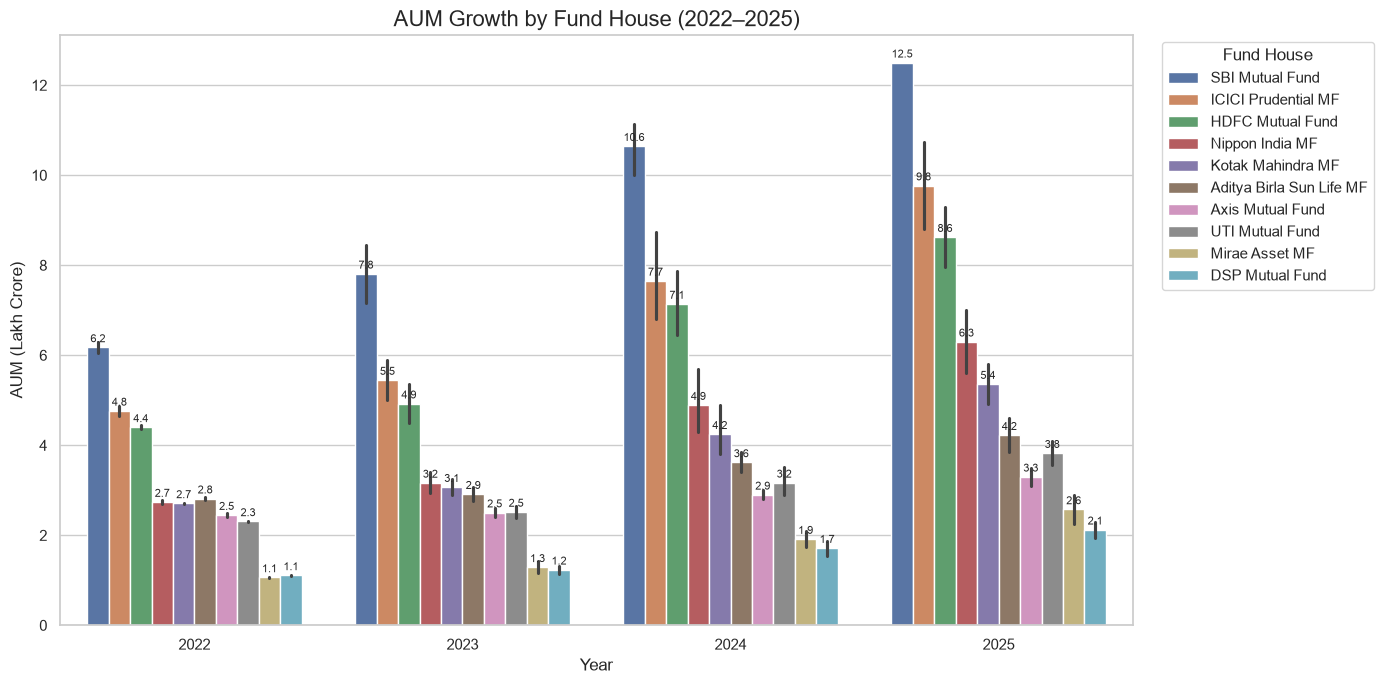

In [31]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)# Add value labels on top of each bar

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.1f",
        fontsize=8,
        padding=2
    )

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=0)

plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

### Business Insight

- SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) throughout the analysis period.
- The AUM of SBI Mutual Fund increased from approximately **6.05 lakh crore in 2022** to **12.5 lakh crore in 2025**, demonstrating strong investor confidence and sustained growth.
- ICICI Prudential Mutual Fund and HDFC Mutual Fund also showed consistent growth but remained below SBI.
- Overall, the mutual fund industry experienced steady AUM growth from 2022 to 2025, indicating increasing participation by investors.

In [32]:
plt.savefig(
    "../reports/AUM_Growth_by_Fund_House.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# 6. SIP Inflow Time Series Analysis

Systematic Investment Plan (SIP) inflow represents the monthly investments made by investors into mutual funds. This analysis visualizes the growth of SIP investments over time.

## Import Required Libraries

Import the necessary libraries for data manipulation and interactive visualization.

In [51]:
import pandas as pd
import plotly.express as px

## Preview the SIP Dataset

Display the first few records of the dataset to understand its structure.

In [52]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


## Inspect Dataset Information

Check the column names, data types, and missing values before visualization.

In [53]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


## Convert the Month Column

Convert the month column into datetime format so Plotly can correctly interpret the timeline.

In [54]:
sip["month"] = pd.to_datetime(sip["month"])

## Find the Peak SIP Inflow

Identify the month with the highest SIP inflow for annotation.

In [55]:
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

## Prepare Data for Plotly

Convert the datetime values into formatted month labels to avoid serialization issues while exporting the chart.

In [56]:
sip_plot = sip.copy()

sip_plot["month"] = sip_plot["month"].dt.strftime("%b %Y")

## Create the Monthly SIP Inflow Trend

Create an interactive Plotly line chart showing monthly SIP inflows.

In [57]:
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

## Highlight the All-Time Highest SIP Inflow

Annotate the highest monthly SIP inflow of ₹31,002 crore recorded in December 2025.

In [58]:
peak_plot = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=peak_plot["month"],
    y=peak_plot["sip_inflow_crore"],
    text="₹31,002 Cr<br>Dec 2025",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    ax=-60,
    ay=-40,
    bgcolor="yellow",
    bordercolor="black"
)

## Display the Interactive Chart

Render the interactive Plotly visualization.

In [59]:
fig.show()

## Export the Visualization

Save the Plotly chart as a PNG image in the reports folder.

In [60]:
fig.write_image("../reports/SIP_Inflow_Trend.png")

# 7. Category Inflow Heatmap

This analysis visualizes monthly net inflows across different mutual fund categories. A heatmap is used to identify seasonal trends and compare inflow intensity between fund categories over time.

## Import Required Libraries

Import the required libraries for data manipulation and heatmap visualization.

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
import os

os.listdir("../data/processed")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv']

## Load the Category Inflow Dataset

Load the monthly category inflow dataset for analysis.

In [63]:
category = pd.read_csv("../data/processed/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


## Inspect the Dataset

Examine the dataset structure, data types, and column names before creating the heatmap.

In [64]:
category.info()

category.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 6.2 KB


['month', 'category', 'net_inflow_crore']

## Convert the Month Column

Convert the month column into datetime format to ensure proper chronological ordering.

In [65]:
category["month"] = pd.to_datetime(category["month"])

category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[us]
 1   category          144 non-null    str           
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 4.8 KB


## Format the Month Labels

Create readable month labels (e.g., Jan 2022) for the heatmap.

In [66]:
category["month_label"] = category["month"].dt.strftime("%b %Y")

category[["month", "month_label"]].head()

,month,month_label
0,2024-04-01,Apr 2024
1,2024-04-01,Apr 2024
2,2024-04-01,Apr 2024
3,2024-04-01,Apr 2024
4,2024-04-01,Apr 2024


## Prepare the Heatmap Data

Transform the dataset into a matrix where fund categories form the rows, months form the columns, and net inflows are represented as values.

In [70]:
# Sort the dataset by month
category = category.sort_values("month")

# Create pivot table using datetime
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Convert datetime columns to readable labels
heatmap_data.columns = heatmap_data.columns.strftime("%b %Y")

heatmap_data.head()

month,Apr 2024,May 2024,Jun 2024,Jul 2024,Aug 2024,Sep 2024,Oct 2024,Nov 2024,Dec 2024,Jan 2025,Feb 2025,Mar 2025
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


## Category Inflow Heatmap

Visualize monthly net inflows across mutual fund categories. Darker colors indicate higher net inflows.

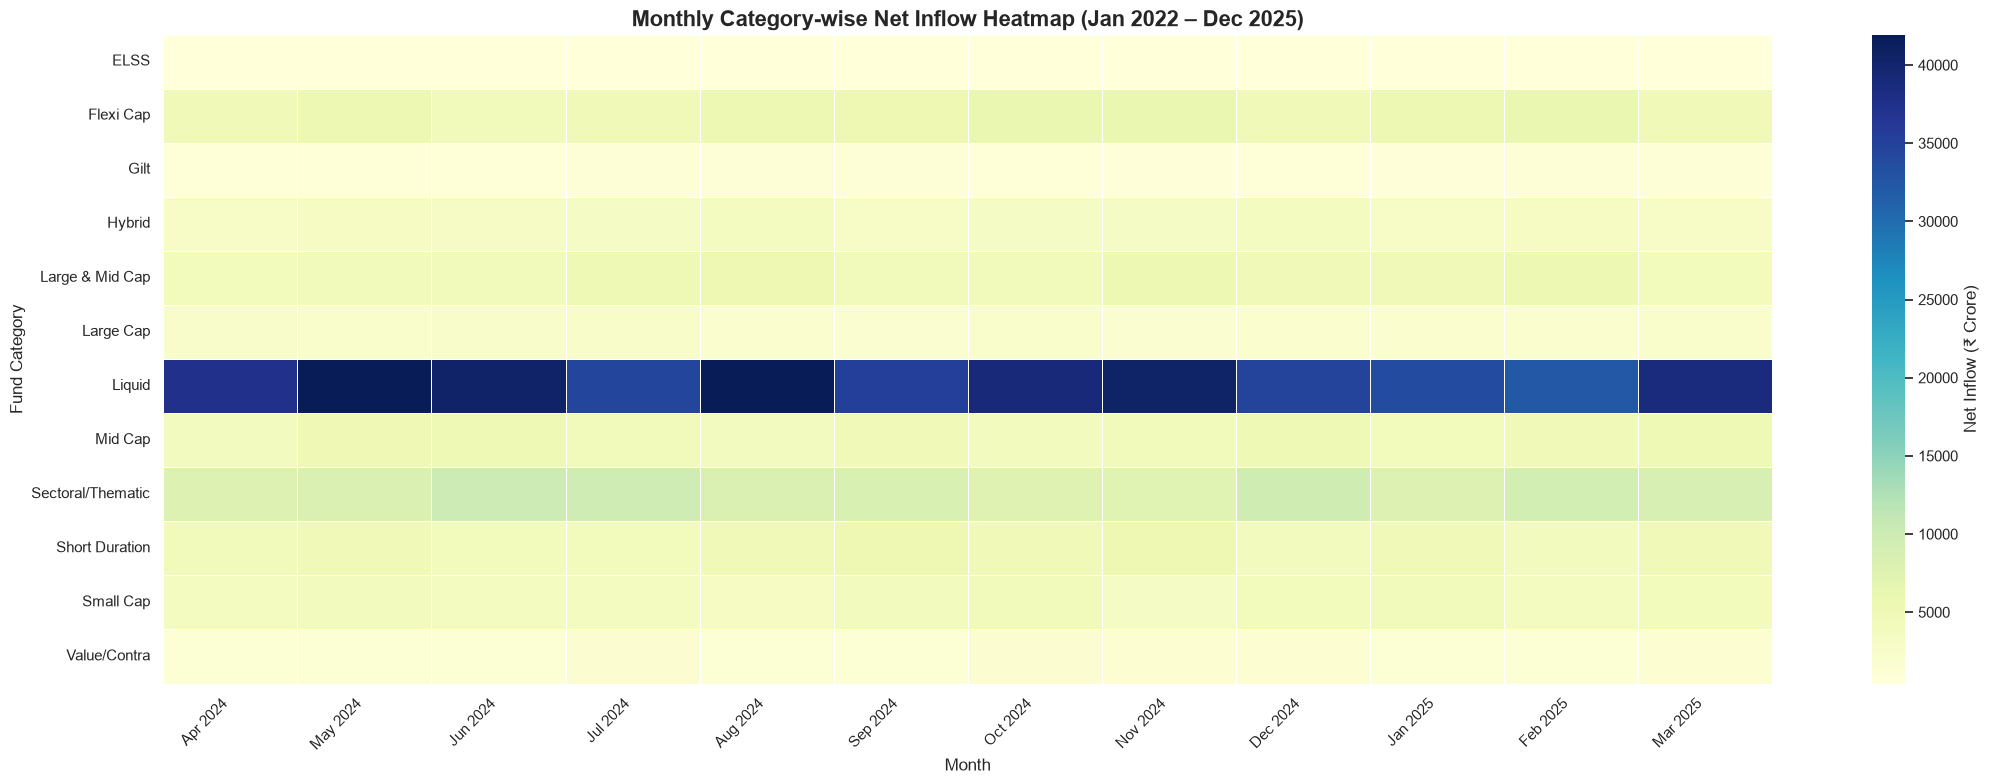

In [71]:
plt.figure(figsize=(22, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Category-wise Net Inflow Heatmap (Jan 2022 – Dec 2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## Export the Visualization

Save the category inflow heatmap as a PNG image for the final report.

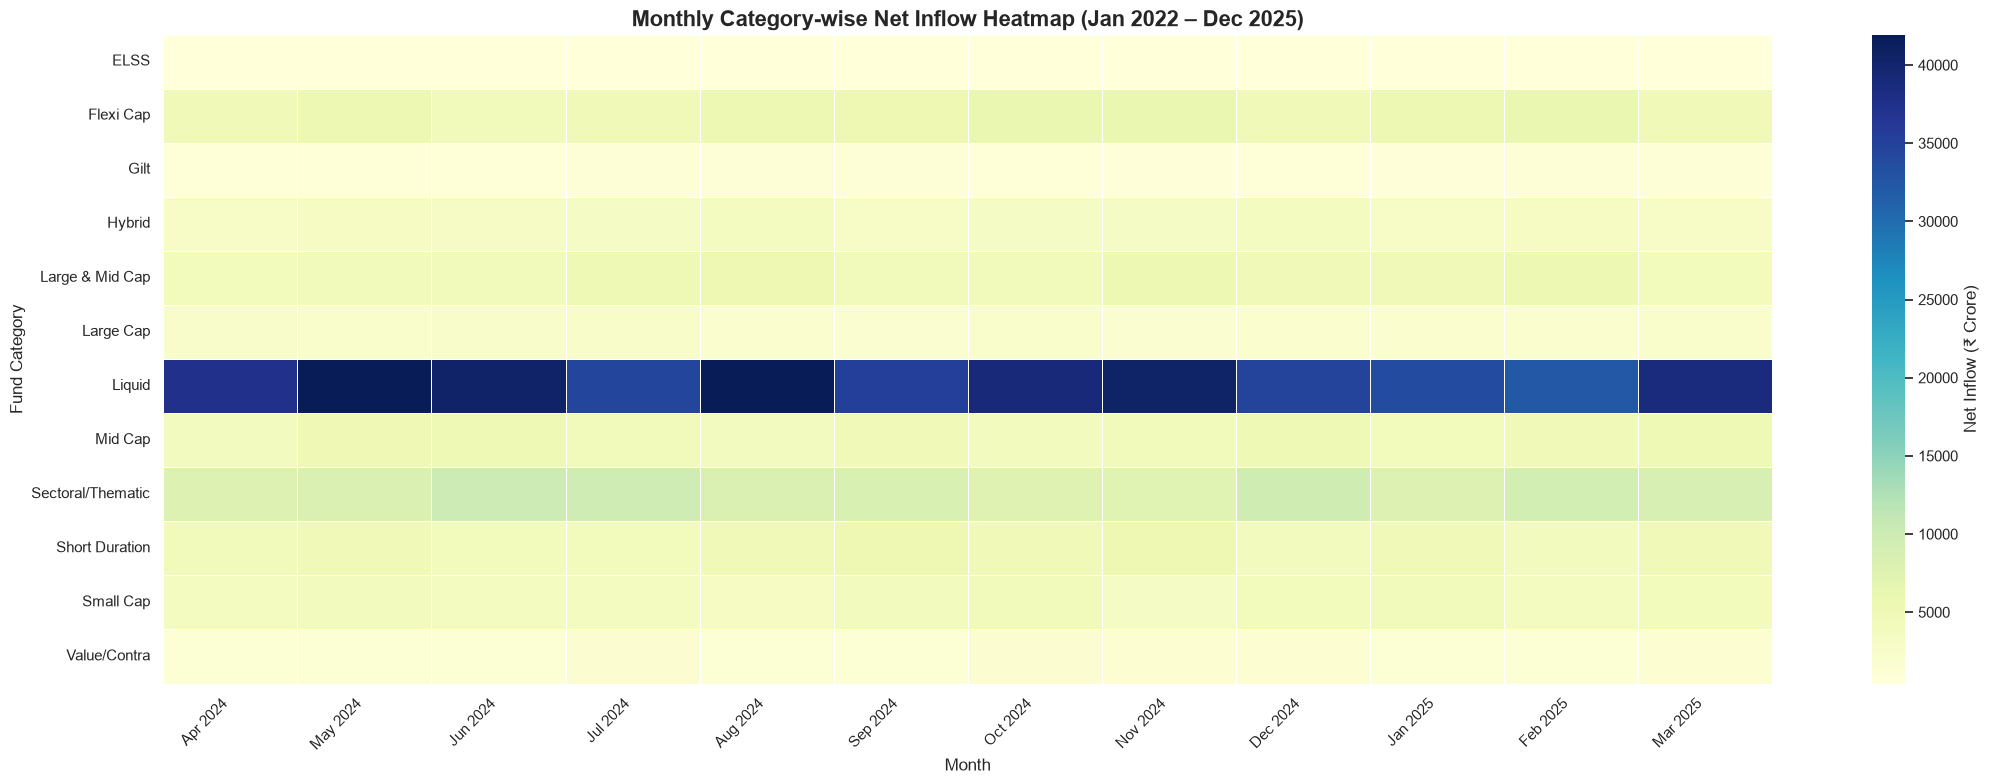

In [75]:
plt.figure(figsize=(22, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Monthly Category-wise Net Inflow Heatmap (Jan 2022 – Dec 2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/Category_Inflow_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
print(category["month"].min())
print(category["month"].max())
print(category["month"].nunique())

2024-04-01 00:00:00
2025-03-01 00:00:00
12


# 8. Investor Demographics Analysis

This analysis explores the demographic profile of mutual fund investors. It examines the distribution of investors across different age groups, compares SIP investment amounts by age group, and visualizes the gender distribution of investors.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [77]:
investor = pd.read_csv("../data/processed/08_investor_transactions.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


## Inspect the Dataset

Check the dataset structure, data types, and available columns before creating visualizations.

In [78]:
investor.info()

investor.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 5.4 MB


['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

## Age Group Distribution

This pie chart shows the proportion of investors across different age groups.

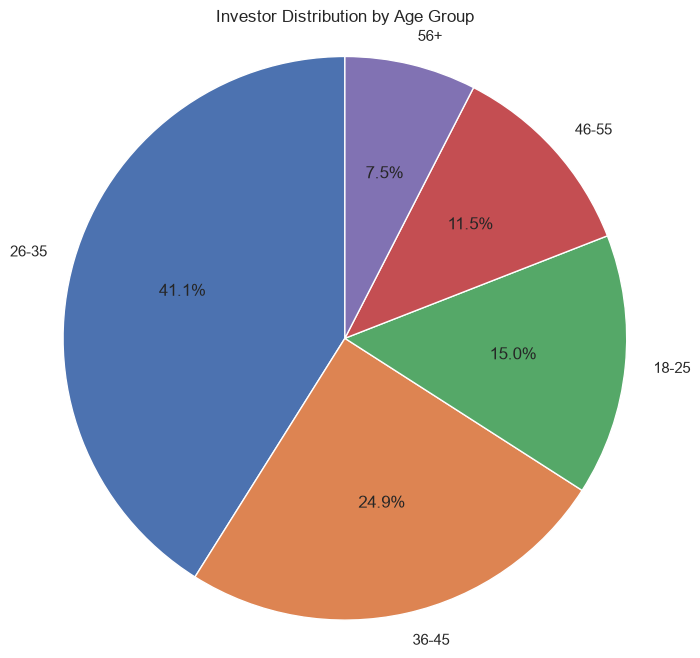

In [79]:
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")
plt.axis("equal")

plt.savefig(
    "../reports/Age_Group_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SIP Amount Distribution by Age Group

The box plot compares SIP investment amounts across different investor age groups and highlights the spread, median, and potential outliers.

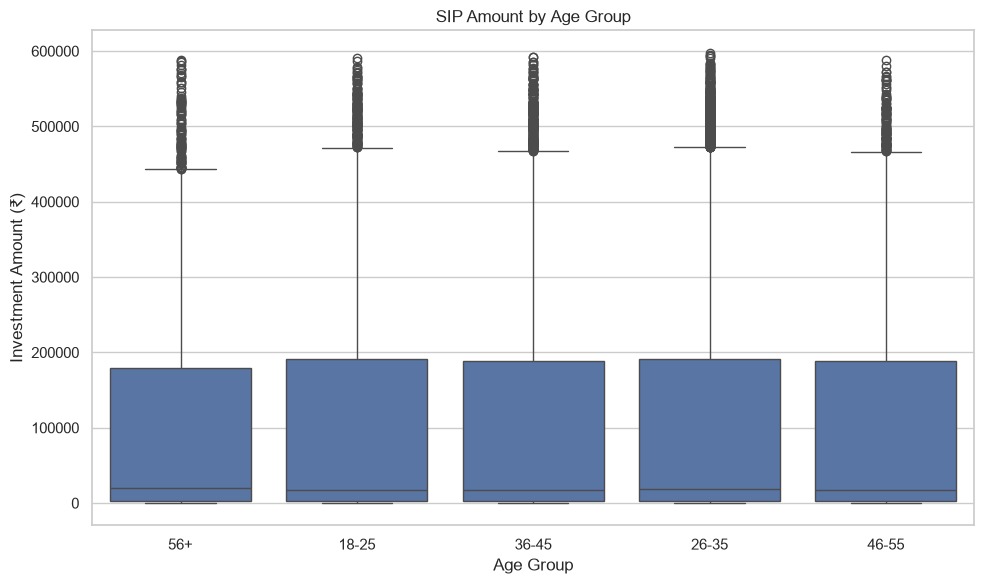

In [80]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/SIP_Boxplot_Age_Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender Distribution

This pie chart illustrates the percentage of male and female investors in the dataset.

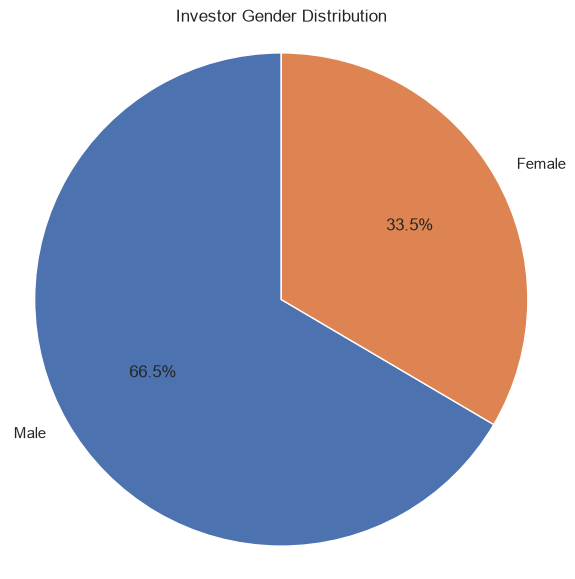

In [81]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.axis("equal")

plt.savefig(
    "../reports/Gender_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 9. Geographic Distribution Analysis

This analysis explores the geographical distribution of mutual fund investments across Indian states and city tiers. It highlights the total SIP investment amount by state and compares investments between T30 and B30 cities.

## Total SIP Amount by State

The horizontal bar chart displays the total SIP investment amount contributed by investors from each state.

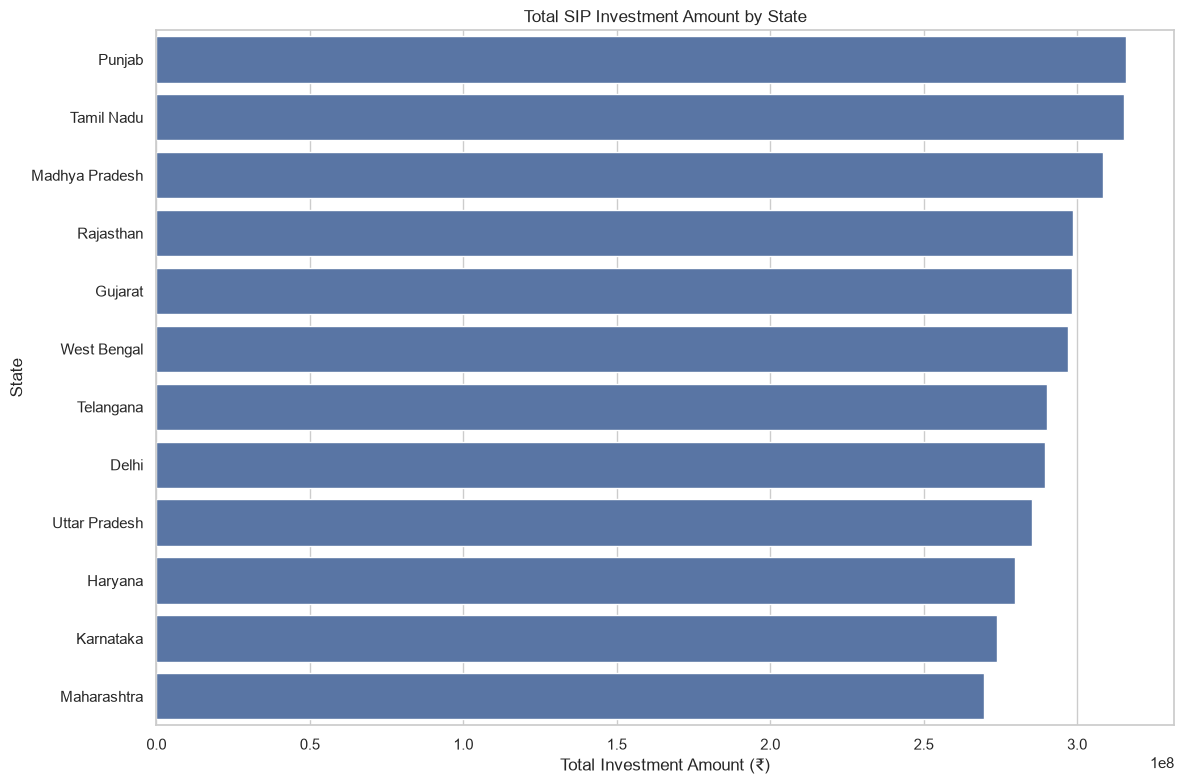

In [82]:
state_sip = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/State_Wise_SIP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## T30 vs B30 City Distribution

This pie chart compares the proportion of investor transactions from T30 and B30 cities.

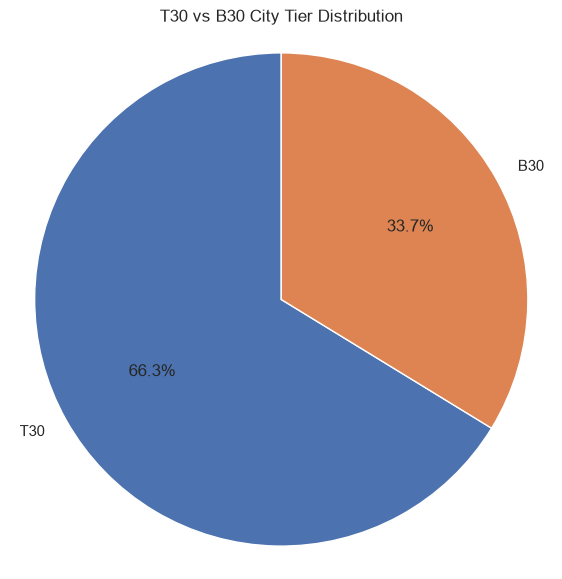

In [83]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.axis("equal")

plt.savefig(
    "../reports/City_Tier_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
import os

os.listdir("../data/processed")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv']

# 10. Folio Count Growth Analysis

This analysis visualizes the growth in mutual fund folios over time. It highlights the increase in total folio count from January 2022 to December 2025 and marks important milestones in the industry's growth.

## Load the Industry Folio Dataset

Load the processed folio count dataset for time-series analysis.

In [85]:
folio = pd.read_csv("../data/processed/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


## Inspect the Dataset

Check the dataset structure, data types, and available columns before creating the visualization.

In [86]:
folio.info()

folio.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.3 KB


['month',
 'total_folios_crore',
 'equity_folios_crore',
 'debt_folios_crore',
 'hybrid_folios_crore',
 'others_folios_crore']

## Prepare the Data

Convert the month column into datetime format and sort the dataset for accurate time-series visualization.

In [87]:
folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


## Identify Key Milestones

Find the first and last folio values for annotation on the chart.

In [88]:
start = folio.iloc[0]
end = folio.iloc[-1]

print(start)
print(end)

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


## Create the Folio Growth Line Chart

Visualize the growth in mutual fund folios from January 2022 to December 2025 using a line chart.

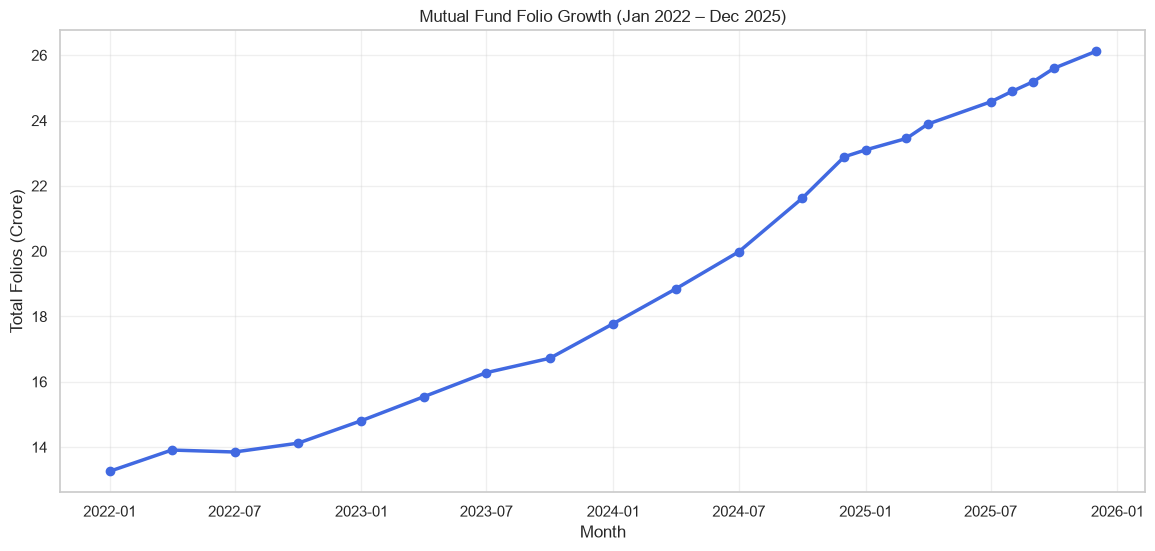

In [89]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Mutual Fund Folio Growth (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(alpha=0.3)

## Highlight Important Milestones

Annotate the beginning and ending folio counts to emphasize the overall growth in mutual fund folios between January 2022 and December 2025.

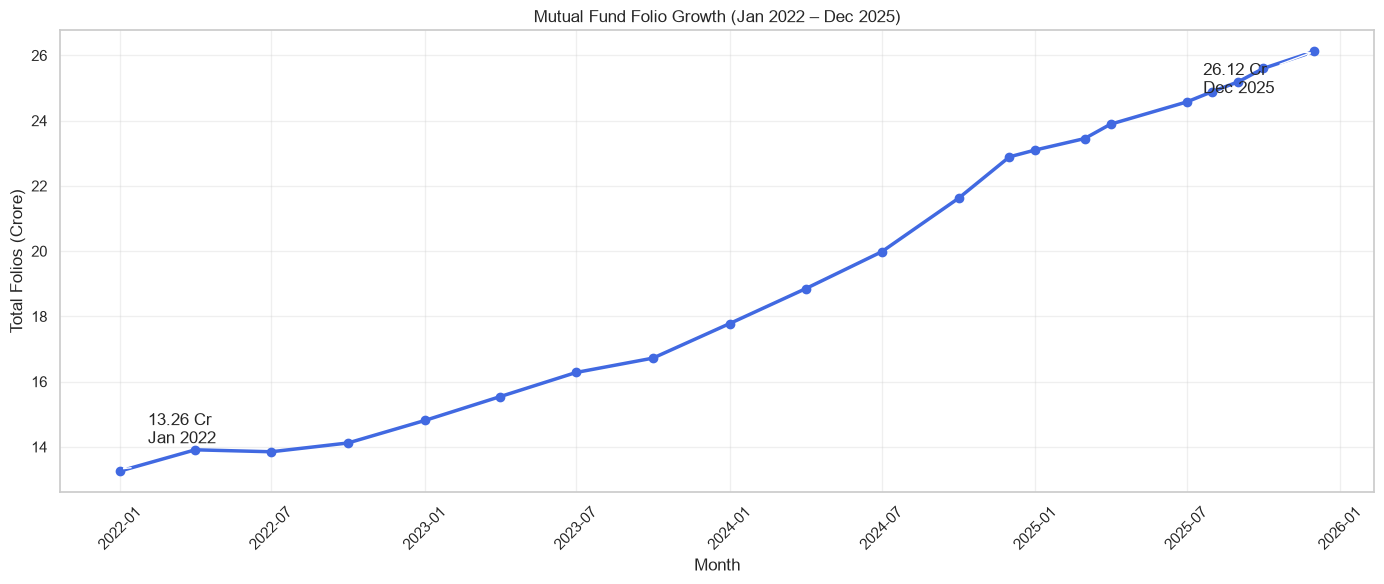

In [90]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

# Starting milestone
plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(start["month"], start["total_folios_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Ending milestone
plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(end["month"], end["total_folios_crore"]),
    xytext=(-80,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Mutual Fund Folio Growth (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Export the Visualization

Save the folio growth chart as a high-resolution PNG image for the final report.

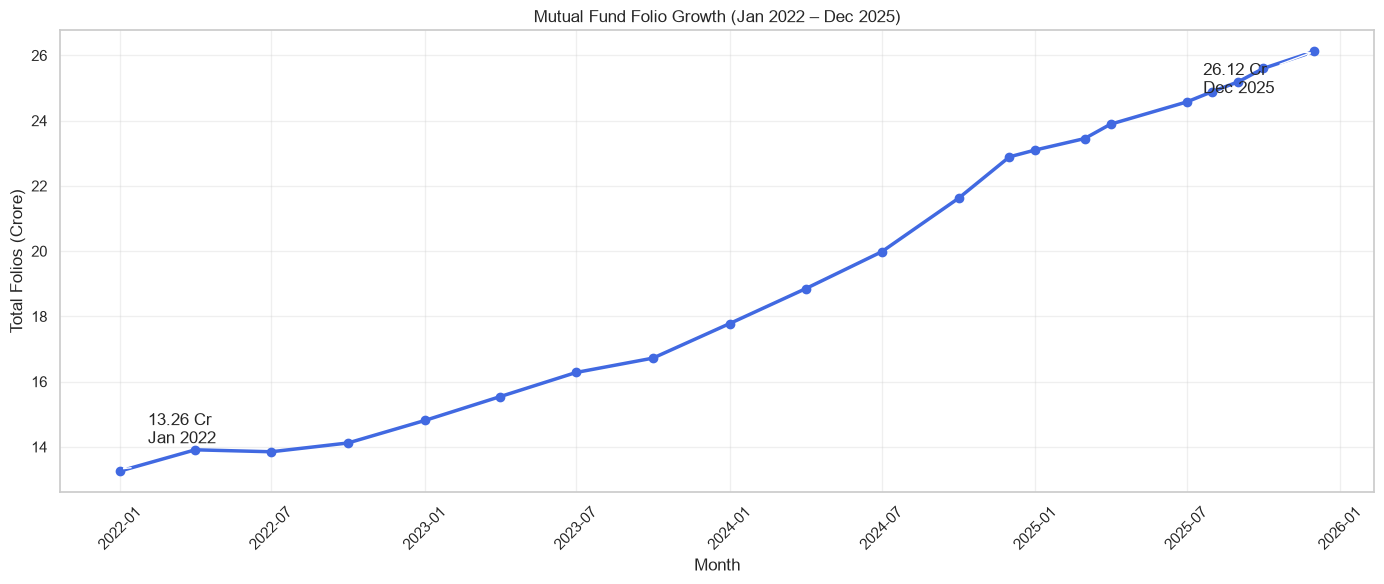

In [91]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(start["month"], start["total_folios_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(end["month"], end["total_folios_crore"]),
    xytext=(-80,-30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Mutual Fund Folio Growth (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/Folio_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. NAV Return Correlation Matrix

Analyze the relationship between the daily returns of selected mutual fund schemes using a correlation heatmap.

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load the NAV History Dataset

Load the daily NAV history containing all mutual fund schemes.

In [93]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Inspect the Dataset

Check the dataset structure, data types, and available columns.

In [94]:
nav.info()

nav.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


['amfi_code', 'date', 'nav']

## Prepare the Data

Convert the date column into datetime format and sort the dataset by fund and date.

In [95]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Select Sample Mutual Funds

Choose 10 mutual fund schemes for correlation analysis.

In [96]:
selected_funds = nav["amfi_code"].unique()[:10]

selected_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

## Filter the Dataset

Keep only the selected 10 mutual fund schemes.

In [97]:
nav_10 = nav[nav["amfi_code"].isin(selected_funds)]

nav_10.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Create NAV Matrix

Arrange NAV values with dates as rows and AMFI codes as columns.

In [98]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


## Calculate Daily Returns

Compute percentage change in NAV to obtain daily returns for each selected fund.

In [99]:
returns = nav_pivot.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360


## Compute Correlation Matrix

Measure pairwise correlation between the daily returns of the selected mutual fund schemes.

In [100]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


## Visualize Correlation Matrix

Create a Seaborn heatmap to visualize the correlation between the daily returns of the selected mutual fund schemes.

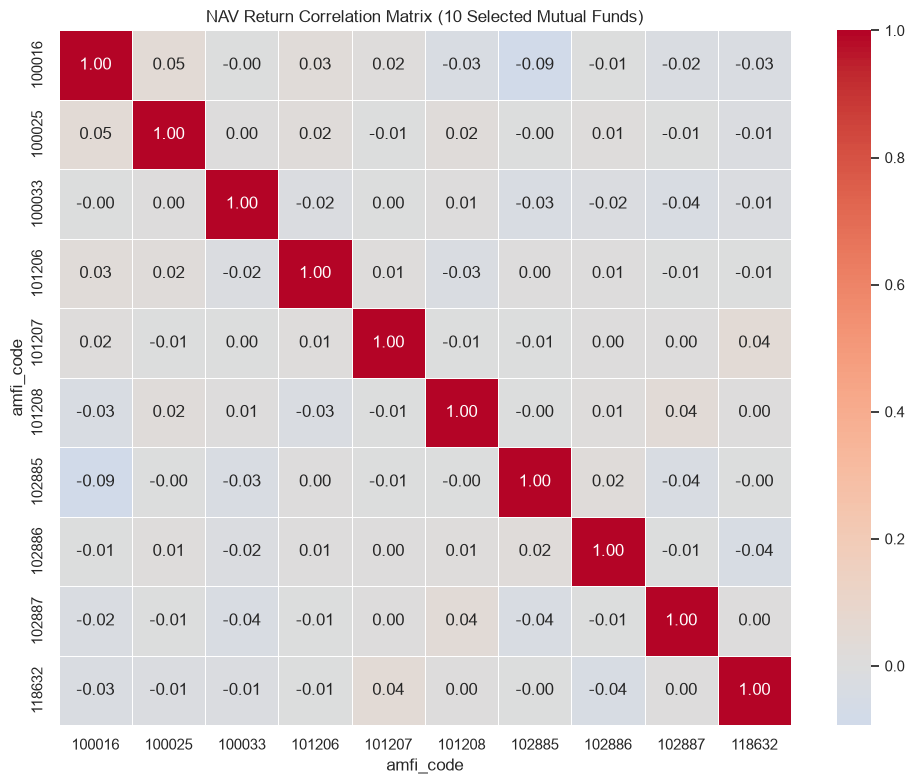

In [101]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (10 Selected Mutual Funds)")
plt.tight_layout()

plt.show()

## Export the Visualization

Save the correlation heatmap as a PNG image for the final report.

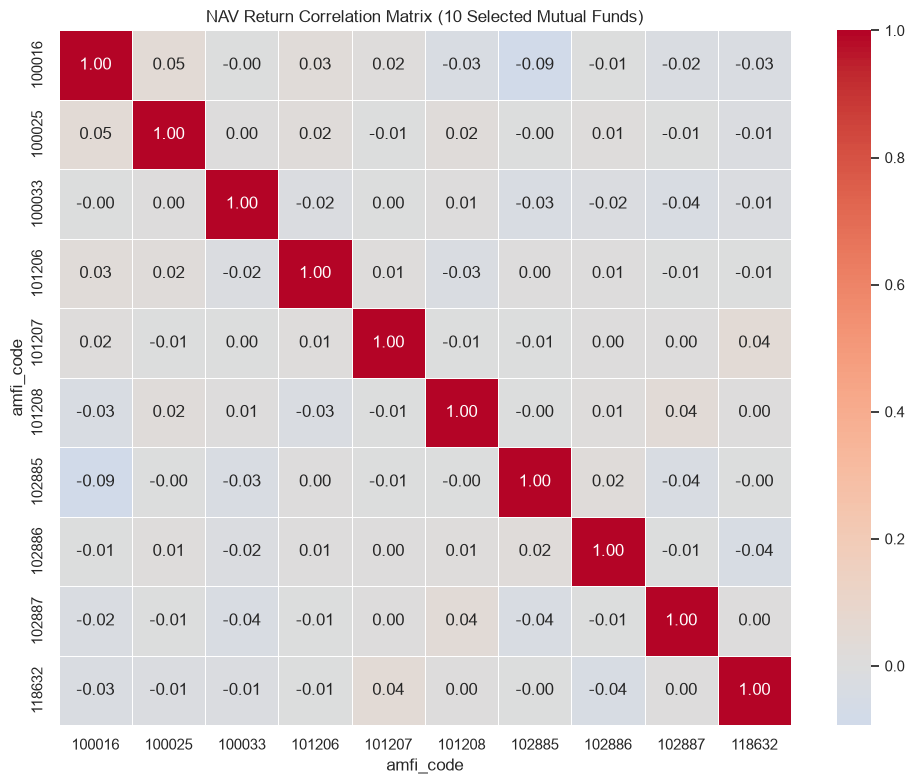

In [102]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (10 Selected Mutual Funds)")

plt.tight_layout()

plt.savefig(
    "../reports/NAV_Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 12. Sector Allocation Donut Chart

Analyze portfolio holdings and visualize the overall sector allocation across equity mutual funds using a donut chart.

## Import Required Libraries

Import the required libraries for data manipulation and visualization.

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the Portfolio Holdings Dataset

Load the portfolio holdings dataset containing sector-wise allocation.

In [104]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


## Inspect the Dataset

Check the dataset structure, data types, and available columns before aggregating sector allocations.


In [105]:
holdings.info()

holdings.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 33.6 KB


['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

## Aggregate Sector Allocation

Calculate the total portfolio allocation for each sector by summing the weight percentages.

In [106]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_alloc

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

## Create Sector Allocation Donut Chart

Visualize the overall sector allocation across equity mutual funds using a donut chart.

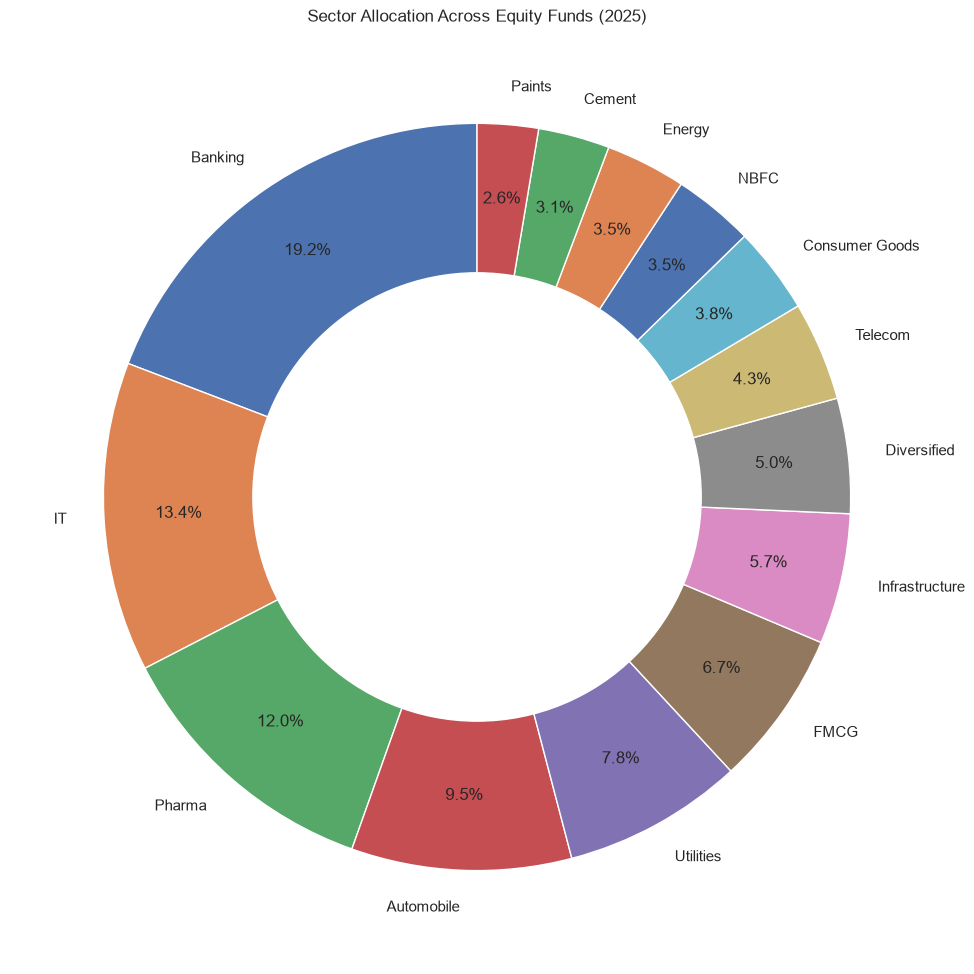

In [107]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

# Create donut hole
centre_circle = plt.Circle((0,0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds (2025)")

plt.tight_layout()

plt.show()

## Export the Visualization

Save the sector allocation donut chart as a PNG image in the reports folder.

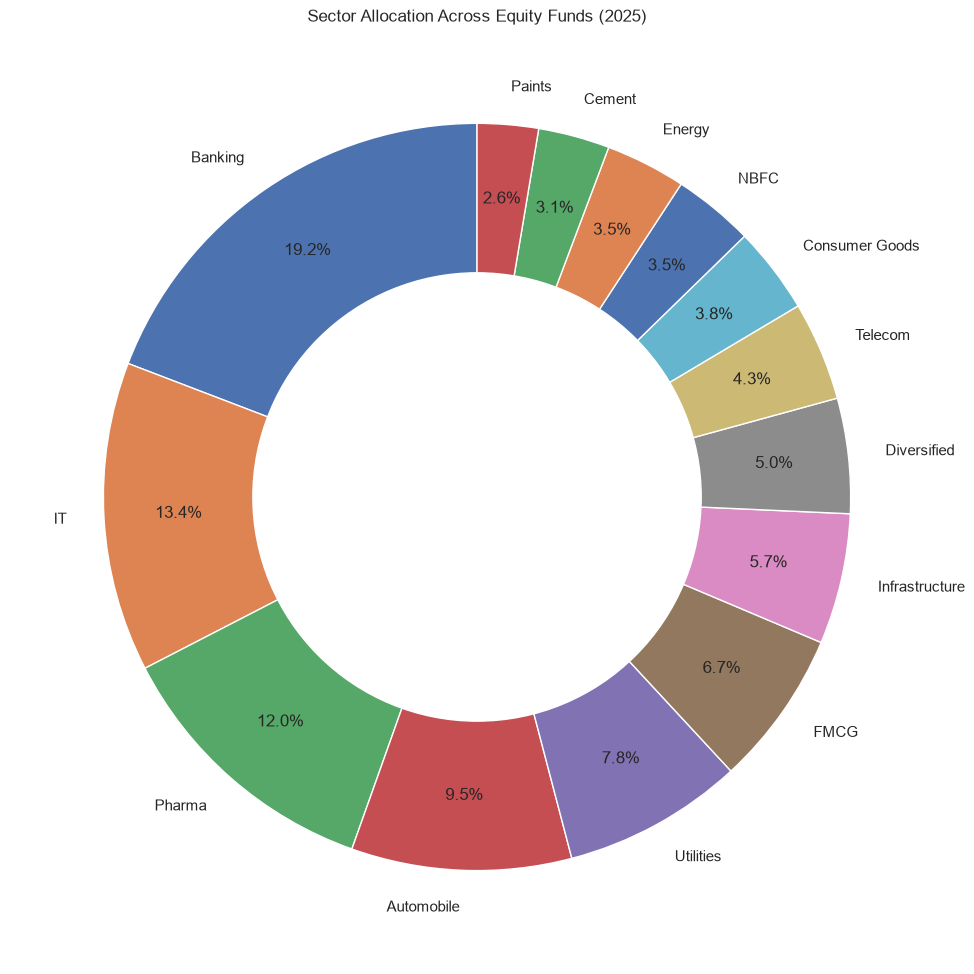

In [108]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

centre_circle = plt.Circle((0,0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds (2025)")

plt.tight_layout()

plt.savefig(
    "../reports/Sector_Allocation_Donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Finding 1

The selected mutual fund schemes showed a strong upward NAV trend from 2022 to 2025, with a noticeable bull run during 2023 and sustained growth throughout 2025.

**Supporting Chart:** NAV Trend Analysis

## Key Finding 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), demonstrating its strong market leadership between 2022 and 2025.

**Supporting Chart:** AUM Growth by Fund House

## Key Finding 3

Monthly SIP inflows increased steadily from January 2022 and reached an all-time high of ₹31,002 Crore in December 2025, reflecting growing investor confidence.

**Supporting Chart:** Monthly SIP Inflow Trend

## Key Finding 4

Liquid funds consistently attracted the highest monthly net inflows, while equity-oriented categories maintained stable long-term investment activity.

**Supporting Chart:** Category Inflow Heatmap

## Key Finding 5

Most investors belonged to the middle-age groups, indicating that working professionals contribute significantly to mutual fund investments.

**Supporting Chart:** Investor Age Group Distribution

## Key Finding 6

Male investors accounted for approximately two-thirds of all investors, while female participation represented about one-third of the total investor base.

**Supporting Chart:** Gender Distribution Pie Chart

## Key Finding 7

T30 cities contributed a substantially larger share of mutual fund investments compared to B30 cities, highlighting stronger participation from metropolitan regions.

**Supporting Chart:** T30 vs B30 City Distribution

## Key Finding 8

Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating continuous expansion of the investor base.

**Supporting Chart:** Mutual Fund Folio Growth

## Key Finding 9

Daily returns of the selected mutual fund schemes exhibited generally low correlations, suggesting effective diversification across different investment portfolios.

**Supporting Chart:** NAV Correlation Matrix

## Key Finding 10

Banking, Information Technology, and Pharma sectors accounted for the largest portfolio allocations, indicating a strong preference for these sectors among equity mutual funds.

**Supporting Chart:** Sector Allocation Donut Chart